In [23]:
## IDW Interpolation Performance Evaluation
# Last updated: 10/30/25

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import rasterio as rio
import matplotlib.ticker as mticker
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
from rasterio.plot import show as rio_show
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio as rio

# PATHS
BASE_DIR = Path().resolve().parent

CONFIG = {
    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir":      BASE_DIR / "Data/Stations",   # per-station CSVs
    "imerg_dir":        BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet":     BASE_DIR / "Data/observations/wy25_mros_obs.parquet",
    "dem_path":         BASE_DIR / "DEM_1km_clipped_v2.tif",
    "out_dir":          BASE_DIR / "outputs/hourly_pipeline",
    "idw_nc":           Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/IDW/hourly_predictors_1km_IDW_v3_test.nc") # too large to store on github so saved locally and in Google Drive data folder
}

VARS = ["mros_plp_proxy", "plp", "temp_air", "temp_wet", "temp_dew", "rh"]
XNAME, YNAME, TNAME = "x", "y", "time"
OUT_DIR = Path(CONFIG["out_dir"])


In [12]:
# LOAD IDW GRID 

print("\n--- Loading IDW dataset ---")
idw = xr.open_dataset(CONFIG["idw_nc"])
print(idw)
print("Variables:", list(idw.data_vars))
print("Time range:", str(idw["time"].values[0]), "→", str(idw["time"].values[-1]))

# LOAD OBSERVATION DATASETS
print("\n--- Loading observations ---")
st_hr   = pd.read_parquet(OUT_DIR / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(OUT_DIR / "hourly_data/imerg_hourly.parquet")
mros_hr  = pd.read_parquet(OUT_DIR / "hourly_data/mros_hourly.parquet")
print("Stations:", st_hr.shape, "IMERG:", imerg_hr.shape, "MRoS:", mros_hr.shape)




--- Loading IDW dataset ---
<xarray.Dataset> Size: 45MB
Dimensions:         (time: 49, y: 260, x: 146)
Coordinates:
  * y               (y) float64 2kB 4.425e+06 4.424e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.633e+05 1.643e+05 ... 3.018e+05 3.028e+05
  * time            (time) datetime64[ns] 392B 2025-03-30 ... 2025-04-01
Data variables:
    temp_air        (time, y, x) float32 7MB ...
    temp_dew        (time, y, x) float32 7MB ...
    temp_wet        (time, y, x) float32 7MB ...
    rh              (time, y, x) float32 7MB ...
    mros_plp_proxy  (time, y, x) float32 7MB ...
    plp             (time, y, x) float32 7MB ...
    elev            (y, x) float32 152kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162846.25611536083 961.820446988464 0.0 4425513.051449...
Variables: ['temp_air', 'te

In [13]:
# WIDE → LONG CONVERSION
def melt_obs(df, vars_, source):
    df = df.copy()
    df = df.melt(
        id_vars=["hour_utc", "lat", "lon", "elev"],
        value_vars=[v for v in vars_ if v in df.columns],
        var_name="var", value_name="obs_value"
    )
    df = df.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
    df["source"] = source
    return df

st_long   = melt_obs(st_hr,   ["temp_air","temp_wet","temp_dew","rh"], "stations")
imerg_long= melt_obs(imerg_hr,["plp"], "imerg")
mros_long = melt_obs(mros_hr, ["mros_plp_proxy"], "mros")

obs_all = pd.concat([st_long, imerg_long, mros_long], ignore_index=True)
print(f"\nCombined observations: {obs_all.shape[0]} records")


Combined observations: 9204960 records


In [14]:
# DATETIME HANDLING
print("\n--- Checking time formats (tz-aware vs naive) ---")
print("Observation time dtype:", obs_all["time"].dtype)
print("IDW time dtype:", idw["time"].dtype)

# Ensure tz-naive alignment
obs_all["time"] = pd.to_datetime(obs_all["time"], utc=True).dt.floor("h").dt.tz_localize(None)
idw_times = pd.to_datetime(idw["time"].values).tz_localize(None)

print("Obs time example:", obs_all["time"].iloc[0])
print("IDW time example:", idw_times[0])

# Filter observations within IDW time window
obs_all = obs_all[
    (obs_all["time"] >= idw_times.min()) &
    (obs_all["time"] <= idw_times.max())
]
print(f"Filtered to {obs_all['time'].min()} → {obs_all['time'].max()}")


--- Checking time formats (tz-aware vs naive) ---
Observation time dtype: datetime64[ns, UTC]
IDW time dtype: datetime64[ns]
Obs time example: 2024-10-01 08:00:00
IDW time example: 2025-03-30 00:00:00
Filtered to 2025-03-30 00:00:00 → 2025-04-01 00:00:00



--- Loading DEM and ensuring projected CRS ---
DEM is geographic (EPSG:4326); reprojecting to EPSG:26911 ...
DEM CRS: EPSG:26911, pixel size: 961.82 m

--- Reprojecting observation coordinates to DEM CRS ---
Obs X range: 141892.1651359729 → 410306.4481214098
Obs Y range: 3934545.6594123975 → 4429683.458391626
Grid X range: 163327.16633885505 → 302791.13115218235
Grid Y range: 4175920.6454562386 → 4425032.141226251


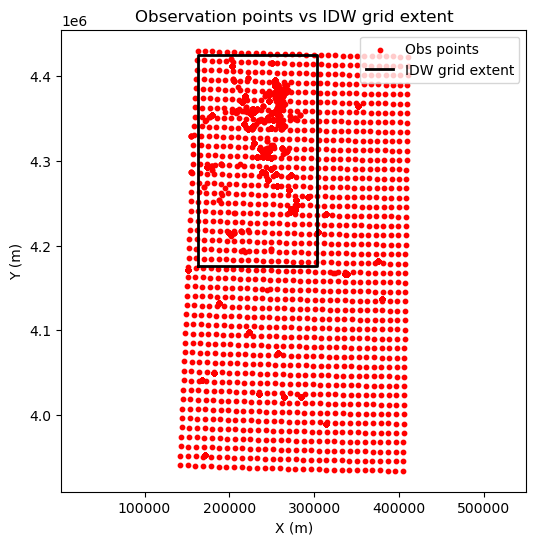

In [24]:
# REPROJECT COORDINATES TO MATCH IDW GRID CRS

# LOAD AND VERIFY DEM CRS
print("\n--- Loading DEM and ensuring projected CRS ---")

# Optional fallback projection
CONFIG["proj_fallback"] = "EPSG:26911"   # NAD83 / UTM zone 11N (units: meters)

def grid_centers(profile):
    """Compute projected x,y coordinates (in meters) for every pixel center in the DEM."""
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

with rio.open(CONFIG["dem_path"]) as src:
    dem_crs = src.crs
    if not dem_crs or not dem_crs.is_projected:
        print(f"DEM is geographic ({dem_crs}); reprojecting to {CONFIG['proj_fallback']} ...")
        dst_crs = CONFIG["proj_fallback"]
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
        dem_data = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rio.band(src, 1),
            destination=dem_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        dem_profile = kwargs
        proj_crs = dst_crs
    else:
        dem_profile = src.profile
        dem_data = src.read(1)
        proj_crs = dem_crs

grid_xy = grid_centers(dem_profile)
print(f"DEM CRS: {proj_crs}, pixel size: {abs(dem_profile['transform'].a):.2f} m")

# REPROJECT OBSERVATION COORDINATES TO DEM CRS
print("\n--- Reprojecting observation coordinates to DEM CRS ---")

transformer = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
lon = obs_all["x"].values
lat = obs_all["y"].values
x_m, y_m = transformer.transform(lon, lat)
obs_all["x"] = x_m
obs_all["y"] = y_m

print("Obs X range:", obs_all["x"].min(), "→", obs_all["x"].max())
print("Obs Y range:", obs_all["y"].min(), "→", obs_all["y"].max())
print("Grid X range:", float(idw["x"].min()), "→", float(idw["x"].max()))
print("Grid Y range:", float(idw["y"].min()), "→", float(idw["y"].max()))

# VISUAL OVERLAP CHECK
plt.figure(figsize=(6,6))
plt.scatter(obs_all["x"], obs_all["y"], s=10, color="red", label="Obs points")
plt.plot(
    [idw["x"].min(), idw["x"].max(), idw["x"].max(), idw["x"].min(), idw["x"].min()],
    [idw["y"].min(), idw["y"].min(), idw["y"].max(), idw["y"].max(), idw["y"].min()],
    color="black", lw=2, label="IDW grid extent"
)
plt.legend()
plt.title("Observation points vs IDW grid extent")
plt.xlabel("X (m)"); plt.ylabel("Y (m)")
plt.axis("equal")
plt.show()


In [26]:
x_min, x_max = float(idw["x"].min()), float(idw["x"].max())
y_min, y_max = float(idw["y"].min()), float(idw["y"].max())

inside_mask = (
    (obs_all["x"] >= x_min) & (obs_all["x"] <= x_max) &
    (obs_all["y"] >= y_min) & (obs_all["y"] <= y_max)
)
coverage = inside_mask.mean() * 100
print(f"{coverage:.1f}% of observation points fall inside the IDW grid extent.")


65.6% of observation points fall inside the IDW grid extent.


In [27]:
# Subset to overlapping points
obs_all = obs_all.loc[inside_mask].copy()
print(f"Using {len(obs_all)} observations within grid extent.")

Using 8638 observations within grid extent.


In [28]:
# SAMPLING FUNCTION --------------------------
def sample_ds_at_points(ds, points_long, var, xname="x", yname="y", tname="time"):
    """Sample gridded variable at observation coordinates + times."""
    sub = points_long.loc[points_long["var"] == var].copy()
    if sub.empty:
        print(f"No data for var {var}")
        return np.full(len(points_long), np.nan)

    results = []
    valid_count = 0
    for t, sub_t in sub.groupby("time"):
        if t not in pd.to_datetime(ds[tname].values):
            continue
        try:
            f_time = ds[var].sel({tname: t}, method="nearest")
            sampled = f_time.interp(
                {xname: xr.DataArray(sub_t[xname].values, dims="obs"),
                 yname: xr.DataArray(sub_t[yname].values, dims="obs")}
            )
            results.append(pd.Series(sampled.values, index=sub_t.index))
            valid_count += len(sub_t)
        except Exception as e:
            print(f"Interpolation failed for {var} at {t}: {e}")
            continue

    if not results:
        print(f"No successful interpolations for {var}")
        return np.full(len(sub), np.nan)

    preds = pd.concat(results).sort_index().values
    print(f"Sampled {valid_count} points for {var}")
    return preds

In [29]:
# COMPUTE METRICS + RESIDUALS
records, resids = [], []

for var in VARS:
    if var not in idw.data_vars:
        print(f"Variable {var} missing in dataset, skipping.")
        continue

    sub = obs_all[obs_all["var"] == var].copy()
    pred = sample_ds_at_points(idw, obs_all, var)
    sub["pred"] = pred
    sub["resid"] = sub["pred"] - sub["obs_value"]

    valid_mask = np.isfinite(sub["pred"]) & np.isfinite(sub["obs_value"])
    if valid_mask.sum() == 0:
        print(f"No valid predictions for {var}")
        continue

    rmse = np.sqrt(np.nanmean(sub.loc[valid_mask, "resid"] ** 2))
    mae  = np.nanmean(np.abs(sub.loc[valid_mask, "resid"]))
    bias = np.nanmean(sub.loc[valid_mask, "resid"])
    n    = valid_mask.sum()

    print(f"{var:15s}  RMSE={rmse:.3f}  MAE={mae:.3f}  Bias={bias:.3f}  N={n}")
    records.append({"var": var, "rmse": rmse, "mae": mae, "bias": bias, "n": n})
    resids.append(sub)

metrics = pd.DataFrame(records)
resid_df = pd.concat(resids, ignore_index=True) if resids else pd.DataFrame()

print("\nMetrics summary:")
print(metrics)

Sampled 475 points for mros_plp_proxy
mros_plp_proxy   RMSE=7.161  MAE=2.356  Bias=-0.028  N=469
Sampled 351 points for plp
plp              RMSE=0.112  MAE=0.058  Bias=-0.003  N=330
Sampled 1953 points for temp_air
temp_air         RMSE=0.229  MAE=0.177  Bias=-0.053  N=1951
Sampled 1953 points for temp_wet
temp_wet         RMSE=0.227  MAE=0.177  Bias=-0.053  N=1951
Sampled 1953 points for temp_dew
temp_dew         RMSE=0.255  MAE=0.194  Bias=-0.051  N=1953
Sampled 1953 points for rh
rh               RMSE=0.084  MAE=0.049  Bias=0.003  N=1953

Metrics summary:
              var      rmse       mae      bias     n
0  mros_plp_proxy  7.161124  2.356469 -0.027879   469
1             plp  0.111797  0.057959 -0.003052   330
2        temp_air  0.228978  0.176842 -0.052902  1951
3        temp_wet  0.227492  0.177218 -0.052702  1951
4        temp_dew  0.254641  0.194345 -0.050757  1953
5              rh  0.084131  0.048819  0.002550  1953
